In [1]:
import os
print(os.getcwd())

C:\Users\dhara\anaconda_projects\Sentiment_Analysis_Amazon_Reviews


In [2]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud

In [3]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv("Reviews.csv")

In [6]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
df.shape

(568454, 10)

In [8]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [9]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [10]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [11]:
def get_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Score'].apply(get_sentiment)

In [12]:
df[['Score', 'Sentiment']].head(10)

,Score,Sentiment
0,5,Positive
1,1,Negative
2,4,Positive
3,2,Negative
4,5,Positive
5,4,Positive
6,5,Positive
7,5,Positive
8,5,Positive
9,5,Positive


In [13]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [14]:
df['Text'].head()

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
Name: Text, dtype: object

In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = text.strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [16]:
sample = df['Text'].iloc[0]

print("Original Review:")
print(sample)

print("\nCleaned Review:")
print(clean_text(sample))

Original Review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned Review:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


In [17]:
df_small = df[['Text', 'Sentiment']].copy()

df_small = df_small.head(50000)

In [18]:
df_small['Cleaned_Text'] = df_small['Text'].apply(clean_text)

In [19]:
df_small[['Text', 'Cleaned_Text']].head()

,Text,Cleaned_Text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [20]:
df_small['Sentiment'].value_counts()

Sentiment
Positive    38418
Negative     7535
Neutral      4047
Name: count, dtype: int64

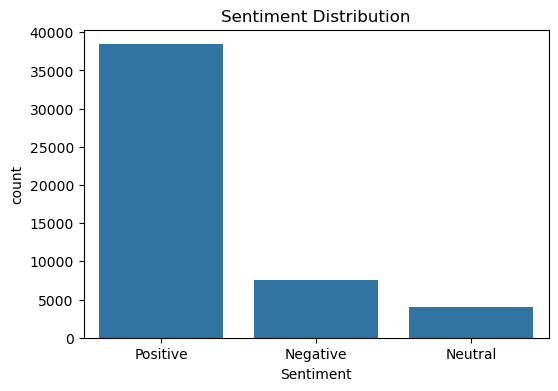

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df_small)
plt.title("Sentiment Distribution")
plt.show()

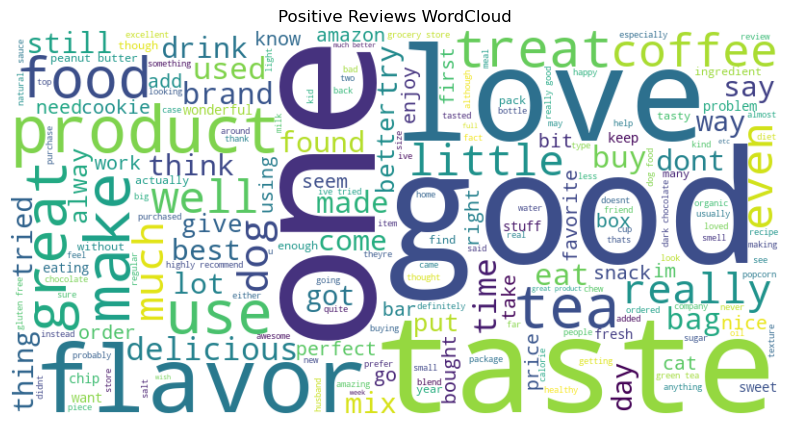

In [22]:
positive_text = " ".join(
    df_small[df_small['Sentiment'] == 'Positive']['Cleaned_Text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

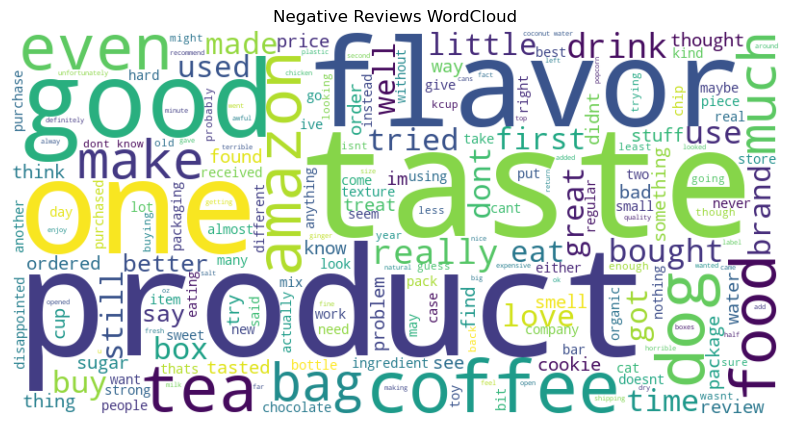

In [23]:
negative_text = " ".join(
    df_small[df_small['Sentiment'] == 'Negative']['Cleaned_Text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

In [24]:
from collections import Counter

negative_words = " ".join(
    df_small[df_small['Sentiment'] == 'Negative']['Cleaned_Text']
).split()

counter = Counter(negative_words)

counter.most_common(20)

[('like', 4134),
 ('taste', 3035),
 ('product', 2879),
 ('one', 2441),
 ('would', 2419),
 ('good', 1892),
 ('flavor', 1792),
 ('coffee', 1779),
 ('dont', 1568),
 ('tea', 1553),
 ('get', 1525),
 ('food', 1505),
 ('even', 1499),
 ('buy', 1343),
 ('much', 1300),
 ('really', 1299),
 ('amazon', 1163),
 ('tried', 1110),
 ('dog', 1105),
 ('first', 1101)]

In [25]:
X = df_small['Cleaned_Text']
y = df_small['Sentiment']

In [26]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

In [27]:
X_tfidf.shape

(50000, 5000)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
X_train.shape, X_test.shape

((40000, 5000), (10000, 5000))

In [30]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
y_pred = model.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8436


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.74      0.61      0.67      1545
     Neutral       0.47      0.12      0.19       838
    Positive       0.87      0.97      0.92      7617

    accuracy                           0.84     10000
   macro avg       0.69      0.57      0.59     10000
weighted avg       0.82      0.84      0.82     10000



In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.74      0.61      0.67      1545
     Neutral       0.47      0.12      0.19       838
    Positive       0.87      0.97      0.92      7617

    accuracy                           0.84     10000
   macro avg       0.69      0.57      0.59     10000
weighted avg       0.82      0.84      0.82     10000



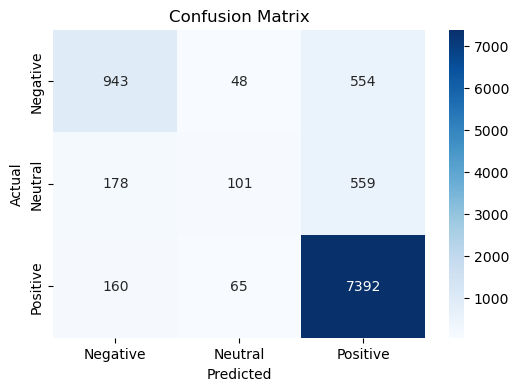

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [36]:
review = ["This product is absolutely amazing and worth every penny"]

review_clean = clean_text(review[0])

review_vector = tfidf.transform([review_clean])

prediction = model.predict(review_vector)

print(prediction[0])

Positive


In [37]:
review = ["Worst product ever. Total waste of money"]

In [38]:
review = ["The product is okay, nothing special"]

review_clean = clean_text(review[0])

review_vector = tfidf.transform([review_clean])

prediction = model.predict(review_vector)

print(prediction[0])

Neutral


In [39]:
review = ["Worst product ever. Total waste of money"]

review_clean = clean_text(review[0])

review_vector = tfidf.transform([review_clean])

prediction = model.predict(review_vector)

print(prediction[0])

Negative


In [40]:
import pickle

pickle.dump(model, open('sentiment_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

In [41]:
loaded_model = pickle.load(open('sentiment_model.pkl', 'rb'))
loaded_tfidf = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))

review = ["I love this product"]

review_clean = clean_text(review[0])
review_vector = loaded_tfidf.transform([review_clean])

prediction = loaded_model.predict(review_vector)

print(prediction[0])

Positive
